# ==========================================
# PARTIE 2 : MODÉLISATION ET ÉVALUATION
# ==========================================

Le tableau ci-dessous synthétise la répartition des tâches et la stratégie adoptée pour répondre aux problématiques métier (BO) via la Data Science (DSO).

| BO (Business Objective) | DSO (Data Science Objective) | Modèles utilisés | Étudiants affectés |
| :--- | :--- | :--- | :--- |
| **BO 1 :** réduction des pertes financières | **DSO 1 :** Construire des modèles capables de prédire les déviations de coût  | **LR,SVR,RF, Gradient Boosting,XGB** | [MEDDEB OUSSEMA] |
| **BO 2 :** amélioration de la planification | **DSO 2 :** Réduire les dépassements de budget et de délai dans les projets de construction.| ** "" ** | [MED HBIB DHAOUADI] |
| **BO 3 :** optimiser l’allocation des ressources et améliorer l’efficacité opérationnelle. | **DSO 3 :** Segmenter les chantiers en profils homogènes selon leur niveau d’utilisation des équipements et de consommation énergétique | ** ACP,K-MEANS,DBSCAN ** | [Yassine SAYARI] |
| **BO 4 :**  | **DSO 4 :** Equipement Utilization Classification &Intelligent Prediction of Equipment Operational Status. | ** arbre de décision , RF, XGB, SVM** | [Youssef DHIB & ABDOU JLASSI] |


# Machine Learning Project
## Construction Projects Analysis


## IMPORT DU PROJET

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, classification_report

## CHARGEMENT DU DATASET

### Comment importer des fichiers dans Google Colab

Pour que votre code puisse lire le fichier `construction_project_dataset_dirty.csv`, vous devez d'abord l'importer dans l'environnement Colab. Voici les options les plus courantes :

1.  **Téléchargement direct via l'interface utilisateur de Colab (recommandé pour les petits fichiers temporaires) :**
    *   Cliquez sur l'icône 'Fichiers' (un dossier) dans la barre latérale gauche de Colab.
    *   Cliquez sur l'icône 'Télécharger vers le stockage de session' (une feuille avec une flèche vers le haut).
    *   Sélectionnez votre fichier `construction_project_dataset_dirty.csv` depuis votre ordinateur.
    *   Une fois téléchargé, le fichier sera accessible dans le répertoire `/content/`.

2.  **Téléchargement via du code Python :**
    Vous pouvez exécuter la cellule de code ci-dessous. Elle affichera un bouton pour que vous puissiez sélectionner et télécharger votre fichier.

3.  **Monter Google Drive (recommandé pour les fichiers persistants ou plus volumineux) :**
    Si votre fichier est stocké sur Google Drive, vous pouvez monter votre Drive pour y accéder directement. Exécutez la cellule de code suivante et suivez les instructions pour autoriser l'accès à votre Google Drive.
    ```python
    from google.colab import drive
    drive.mount('/content/drive')
    # Ensuite, vous pourrez accéder à votre fichier via un chemin comme '/content/drive/MyDrive/NomDeVotreDossier/votre_fichier.csv'
    ```

**Veuillez choisir une méthode pour importer `construction_project_dataset_dirty.csv` avant de réexécuter la cellule de chargement du DataFrame.**

In [ ]:
from google.colab import files

# Cette cellule ouvrira un sélecteur de fichiers.
# Téléchargez 'construction_project_dataset_dirty.csv' ici.
files.upload()

{}

In [ ]:
df = pd.read_csv("/content/construction_project_dataset_dirty.csv")

## DATA UNDERSTANDING

In [ ]:
df.head()

,timestamp,temperature,humidity,vibration_level,material_usage,machinery_status,worker_count,energy_consumption,task_progress,cost_deviation,time_deviation,safety_incidents,equipment_utilization_rate,material_shortage_alert,risk_score,simulation_deviation,update_frequency,optimization_suggestion,performance_score
0,2023-01-01 00:00:0x,24.363503,70.834195,29.038952,162.290510,0.0,10.0,394.617852,0.025050,NaN,-4.645563,2.0,84.481661,0.0,23.181975,0.768037,10.0,Optimize Material Usagy,Excellenx
1,2023-01-01 00:01:0z,38.767858,49.671023,26.348582,627.127074,1.0,16.0,334.086917,0.062199,1866.881543,-0.673013,0.0,85.115701,-0.0,64.242931,6.958721,15.0,NaN,NaN
2,2023-01-01 00:02:0y,33.299849,NaN,17.551847,818.981866,0.0,17.0,70.030254,0.141820,NaN,-5.667880,0.0,82.006109,0.0,NaN,8.980785,5.0,Reallocate Workery,Excellenz
3,2023-01-01 00:03:0y,29.966462,64.198507,24.660633,788.025785,1.0,19.0,275.610928,0.169591,-2778.924736,-8.373158,0.0,93.410108,1.0,58.238809,3.295682,5.0,Reallocate Workerz,Excelleny
4,NaN,18.900466,45.120688,NaN,-853.656587,NaN,-32.0,377.220779,0.185736,-2332.484349,-3.455996,0.0,52.694279,0.0,19.748945,0.223819,15.0,Optimize Material Usagy,Excelleny


 ## Shape

In [ ]:
df.shape

(52500, 19)

## Colonnes

In [ ]:
df.columns

Index(['timestamp', 'temperature', 'humidity', 'vibration_level',
       'material_usage', 'machinery_status', 'worker_count',
       'energy_consumption', 'task_progress', 'cost_deviation',
       'time_deviation', 'safety_incidents', 'equipment_utilization_rate',
       'material_shortage_alert', 'risk_score', 'simulation_deviation',
       'update_frequency', 'optimization_suggestion', 'performance_score'],
      dtype='object')

## Types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52500 entries, 0 to 52499
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   timestamp                   47265 non-null  object 
 1   temperature                 47261 non-null  float64
 2   humidity                    47254 non-null  float64
 3   vibration_level             47270 non-null  float64
 4   material_usage              47257 non-null  float64
 5   machinery_status            47257 non-null  float64
 6   worker_count                47251 non-null  float64
 7   energy_consumption          47227 non-null  float64
 8   task_progress               47266 non-null  float64
 9   cost_deviation              47251 non-null  float64
 10  time_deviation              47259 non-null  float64
 11  safety_incidents            47245 non-null  float64
 12  equipment_utilization_rate  47230 non-null  float64
 13  material_shortage_alert     472

## Describe

In [ ]:
df.describe()

,temperature,humidity,vibration_level,material_usage,machinery_status,worker_count,energy_consumption,task_progress,cost_deviation,time_deviation,safety_incidents,equipment_utilization_rate,material_shortage_alert,risk_score,simulation_deviation,update_frequency
count,47261.000000,47254.000000,47270.000000,47257.000000,47257.000000,47251.000000,47227.000000,47266.000000,47251.000000,47259.000000,47245.000000,47230.000000,47234.000000,47271.000000,47227.000000,47246.000000
mean,24.732258,45.050967,22.629357,494.784126,0.628880,24.359336,246.926303,88.371466,-3.752055,0.023914,0.090274,67.446112,0.179087,45.225563,4.494648,8.115290
std,13.988234,27.737103,18.067826,353.673433,0.551812,17.536281,176.577570,44.177829,2882.369889,5.765784,0.317750,35.714616,0.408195,36.114409,3.605213,5.442045
min,-39.985343,-79.985134,-49.988583,-999.510757,-1.000000,-49.000000,-499.830910,-100.000000,-4999.600496,-9.999570,-2.000000,-99.992400,-1.000000,-99.975987,-9.999730,-15.000000
25%,20.255130,32.684433,10.574175,290.508156,0.000000,14.000000,144.434315,100.000000,-2480.878454,-4.985795,0.000000,60.533112,0.000000,21.497311,2.119672,5.000000
50%,26.842278,48.539403,23.892392,526.085178,1.000000,26.000000,261.594519,100.000000,-1.666721,0.081703,0.000000,73.552040,0.000000,47.576840,4.726580,10.000000
75%,33.398010,64.200589,37.009694,761.583494,1.000000,38.000000,380.984760,100.000000,2482.620564,4.988151,0.000000,86.739394,0.000000,73.858870,7.330702,10.000000
max,39.999304,79.998558,49.999469,999.979996,1.000000,49.000000,499.997574,100.000000,4999.822790,9.999966,4.000000,99.999472,1.000000,99.999493,9.999900,15.000000


In [ ]:
df = df.fillna(df.median(numeric_only=True))


## Valeurs manquantes

In [ ]:
df.isnull().sum()

,0
timestamp,5235
temperature,0
humidity,0
vibration_level,0
material_usage,0
machinery_status,0
worker_count,0
energy_consumption,0
task_progress,0
cost_deviation,0


# valeurs uniques

In [ ]:
df.nunique()

,0
timestamp,46528
temperature,45219
humidity,45207
vibration_level,45209
material_usage,45210
machinery_status,3
worker_count,90
energy_consumption,45228
task_progress,1618
cost_deviation,45200


## Visualisations

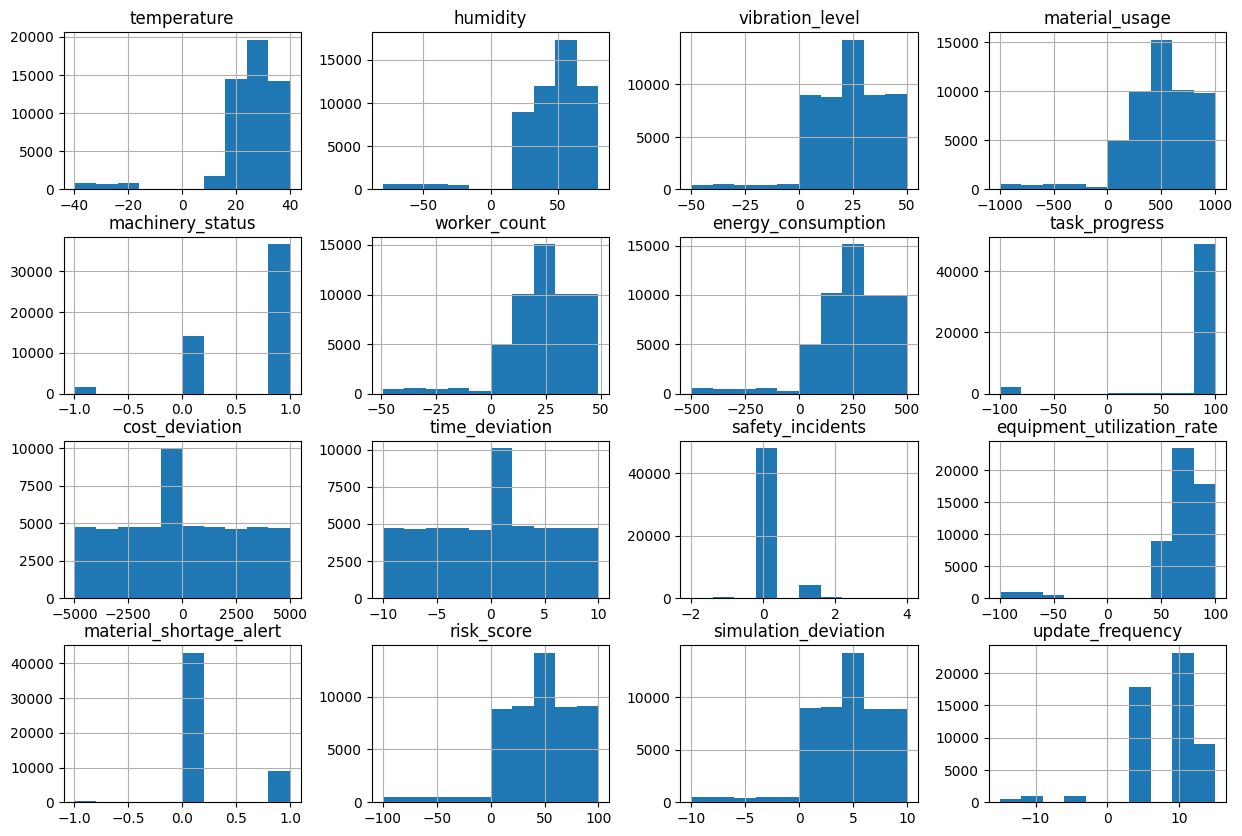

In [ ]:
df.hist(figsize=(15,10))
plt.show()

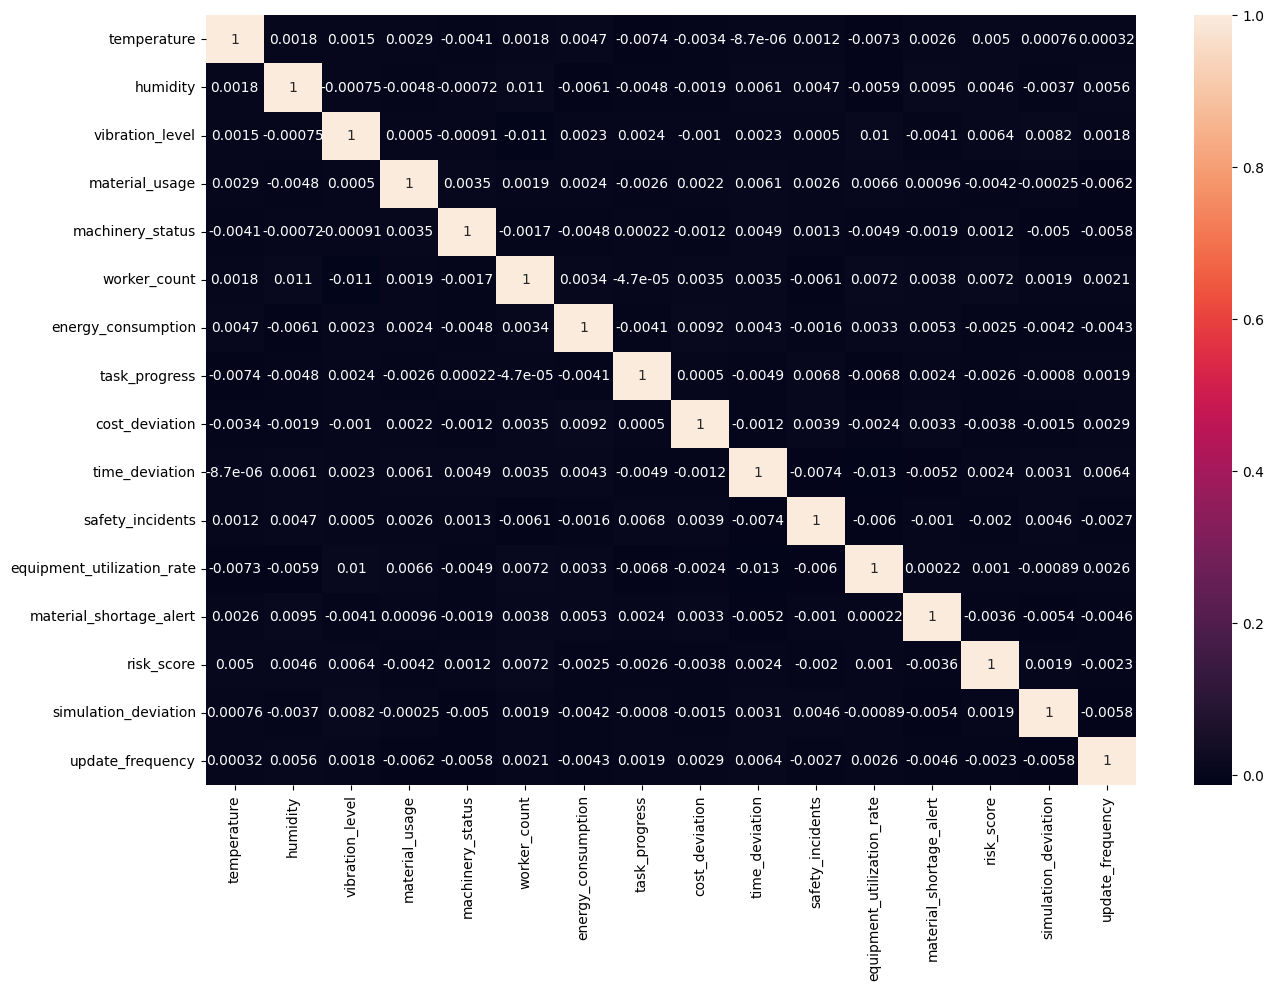

In [ ]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(numeric_only=True),
            annot=True)

plt.show()

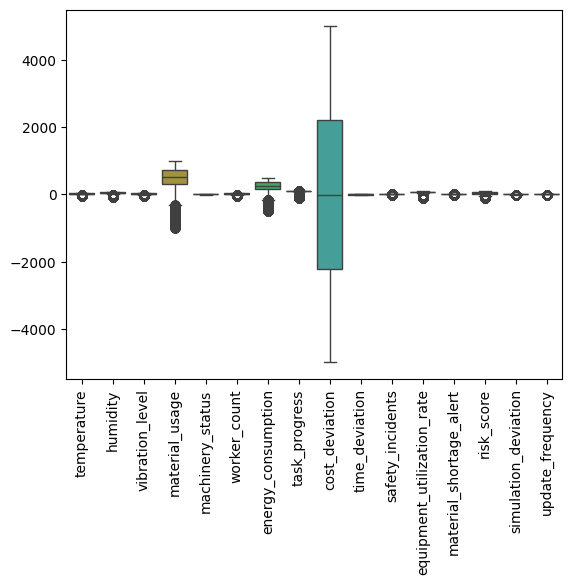

In [ ]:
sns.boxplot(data=df.select_dtypes(include=np.number))

plt.xticks(rotation=90)

plt.show()

## Nettoyage
# Supprimer doublons

In [ ]:
df = df.drop_duplicates()

# valeurs nulles

In [ ]:
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].mean(), inplace=True)
for col in df.select_dtypes(include='object'):
    df[col].fillna("Unknown", inplace=True)
print("Valeurs nulles après nettoyage :")
print(df.isnull().sum())

Valeurs nulles après nettoyage :
timestamp                     0
temperature                   0
humidity                      0
vibration_level               0
material_usage                0
machinery_status              0
worker_count                  0
energy_consumption            0
task_progress                 0
cost_deviation                0
time_deviation                0
safety_incidents              0
equipment_utilization_rate    0
material_shortage_alert       0
risk_score                    0
simulation_deviation          0
update_frequency              0
optimization_suggestion       0
performance_score             0
dtype: int64


/tmp/ipykernel_3951/2978394921.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_3951/2978394921.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

# Nettoyage des valeurs aberrantes

In [ ]:
for col in df.select_dtypes(include=np.number):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Shape après suppression des outliers :")
print(df.shape)

Shape après suppression des outliers :
(25315, 19)


In [ ]:
print("Valeurs nulles :")
print(df.isnull().sum())

print("\nDoublons :")
print(df.duplicated().sum())

print("\nStatistiques :")
print(df.describe())

Valeurs nulles :
timestamp                     0
temperature                   0
humidity                      0
vibration_level               0
material_usage                0
machinery_status              0
worker_count                  0
energy_consumption            0
task_progress                 0
cost_deviation                0
time_deviation                0
safety_incidents              0
equipment_utilization_rate    0
material_shortage_alert       0
risk_score                    0
simulation_deviation          0
update_frequency              0
optimization_suggestion       0
performance_score             0
dtype: int64

Doublons :
0

Statistiques :
        temperature      humidity  vibration_level  material_usage  \
count  25315.000000  25315.000000     25315.000000    25315.000000   
mean      27.422442     49.764865        24.266089      539.613022   
std        6.803119     16.373268        14.511081      255.848709   
min       15.000138     20.001761       -23.197684  

## categorielles


In [ ]:
df['performance_score'].fillna('Medium',inplace=True)

/tmp/ipykernel_3951/642157221.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['performance_score'].fillna('Medium',inplace=True)


## ENCODING

In [ ]:
le = LabelEncoder()

df['performance_score']=le.fit_transform(df['performance_score'])

df['optimization_suggestion']=le.fit_transform(
df['optimization_suggestion'].astype(str))

## Correction erreurs données
# worker_count négatif

In [ ]:
df['worker_count']=abs(df['worker_count'])

## material_usage négatif

In [ ]:
df['material_usage']=abs(df['material_usage'])

## Normalisation

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_numerique = df.select_dtypes(include=['number']) # On ne garde que les chiffres
df_scaled = scaler.fit_transform(df_numerique)

## ACP

# PCA variance

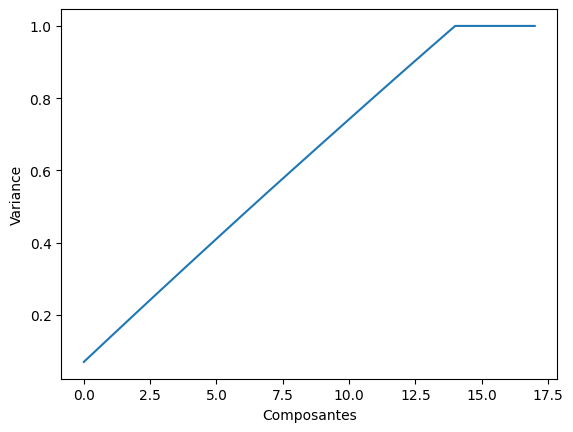

In [ ]:
pca = PCA()

pca_data = pca.fit_transform(df_scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_))

plt.xlabel("Composantes")

plt.ylabel("Variance")

plt.show()

# PCA 90%

In [ ]:
pca = PCA(n_components=0.9)

pca_data = pca.fit_transform(df_scaled)

pca_data.shape

(25315, 14)

# Visualisation PCA

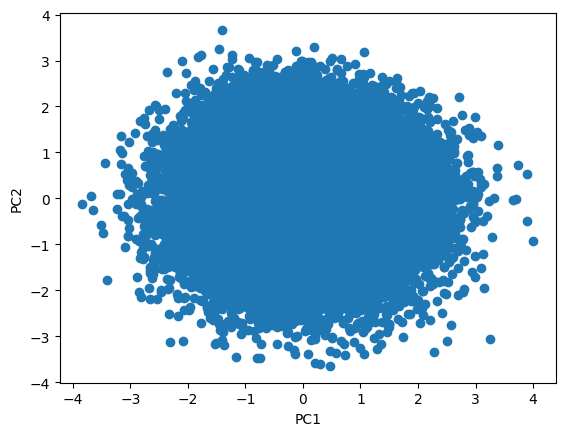

In [ ]:
plt.scatter(pca_data[:,0],pca_data[:,1])

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.show()

# Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('performance_score', axis=1)
y = df['performance_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 ## Vérification complète du dataset

========== VERIFICATION DATASET ==========

1 Shape du dataset :
(25315, 19)

2 Valeurs manquantes :
timestamp                     0
temperature                   0
humidity                      0
vibration_level               0
material_usage                0
machinery_status              0
worker_count                  0
energy_consumption            0
task_progress                 0
cost_deviation                0
time_deviation                0
safety_incidents              0
equipment_utilization_rate    0
material_shortage_alert       0
risk_score                    0
simulation_deviation          0
update_frequency              0
optimization_suggestion       0
performance_score             0
dtype: int64
Dataset propre : Pas de valeurs manquantes

3 Doublons :
0
Dataset propre : Pas de doublons

4 Types de données :
timestamp                      object
temperature                   float64
humidity                      float64
vibration_level               float64
material_usa

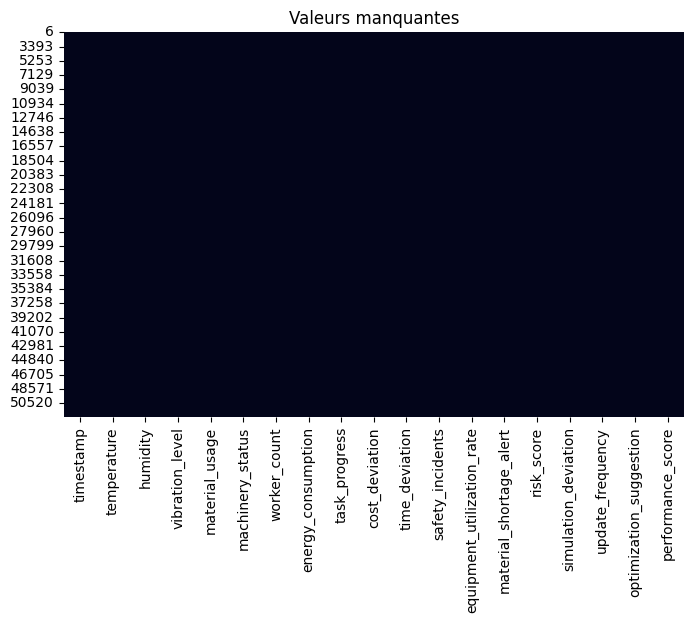

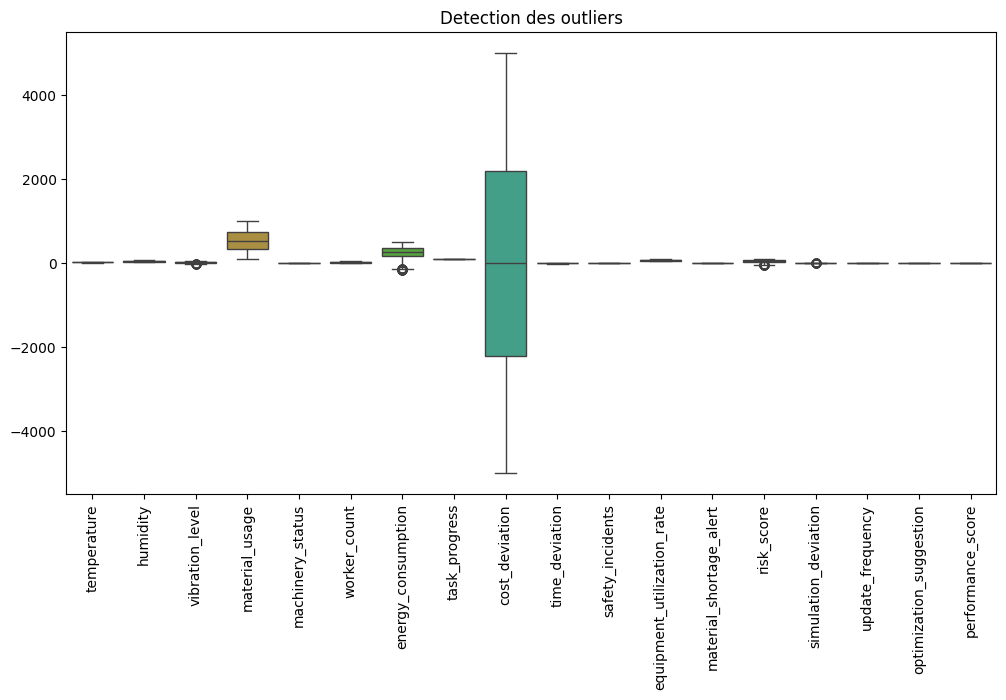


========== RESULTAT FINAL ==========
Dataset propre et pret pour Machine Learning


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("========== VERIFICATION DATASET ==========\n")

# 1 Shape
print("1 Shape du dataset :")
print(df.shape)


# 2 Valeurs manquantes
print("\n2 Valeurs manquantes :")
missing = df.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("Dataset propre : Pas de valeurs manquantes")
else:
    print("Dataset contient des valeurs manquantes")


# 3 Doublons
print("\n3 Doublons :")
duplicates = df.duplicated().sum()
print(duplicates)

if duplicates == 0:
    print("Dataset propre : Pas de doublons")
else:
    print("Dataset contient des doublons")


# 4 Types de données
print("\n4 Types de données :")
print(df.dtypes)


# 5 Valeurs négatives
print("\n5 Valeurs negatives :")

num_cols = df.select_dtypes(include=np.number).columns
negative_values = (df[num_cols] < 0).sum()

print(negative_values)

if negative_values.sum() == 0:
    print("Pas de valeurs negatives")
else:
    print("Valeurs negatives detectees")


# 6 Statistiques
print("\n6 Statistiques Describe:")
print(df.describe())


# 7 Valeurs infinies
print("\n7 Valeurs infinies :")

inf_values = np.isinf(df[num_cols]).sum()

print(inf_values)

if inf_values.sum() == 0:
    print("Pas de valeurs infinies")
else:
    print("Valeurs infinies detectees")


# 8 Heatmap valeurs manquantes
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Valeurs manquantes")
plt.show()


# 9 Boxplot Outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Detection des outliers")
plt.show()


print("\n========== RESULTAT FINAL ==========")

if missing.sum()==0 and duplicates==0 and inf_values.sum()==0:
    print("Dataset propre et pret pour Machine Learning")
else:
    print("Dataset necessite nettoyage")

In [ ]:
df.to_csv("construction_project_dataset_clean.csv", index=False)

Rapport

In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.0 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df)

profile.to_file("rapport.html")

/tmp/ipykernel_3951/2108891707.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install data-profiling via `pip install data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 19/19 [00:01<00:00, 10.86it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

 ** DSO 1 MODÈLE COÛT**


========== MODÈLE COÛT ==========

🔹 Linear Regression
R²=0.7600 | MAE=684.76 | CV=0.7722

🔹 SVR
Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
R²=0.3072 | MAE=1174.36 | CV=0.2846

🔹 Random Forest
Best params: {'max_depth': 12, 'n_estimators': 150}
R²=0.7343 | MAE=723.11 | CV=0.7465

🔹 Gradient Boosting
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
R²=0.7536 | MAE=695.29 | CV=0.7643

🔹 XGBoost
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
R²=0.7551 | MAE=694.18 | CV=0.7658


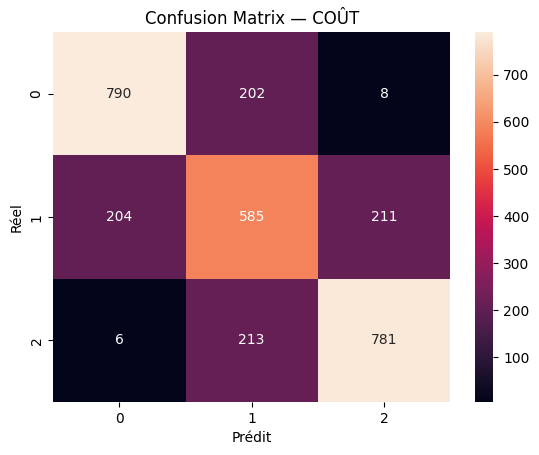

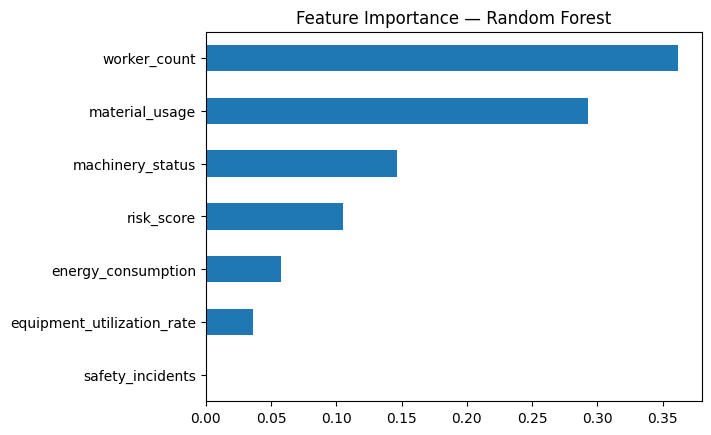

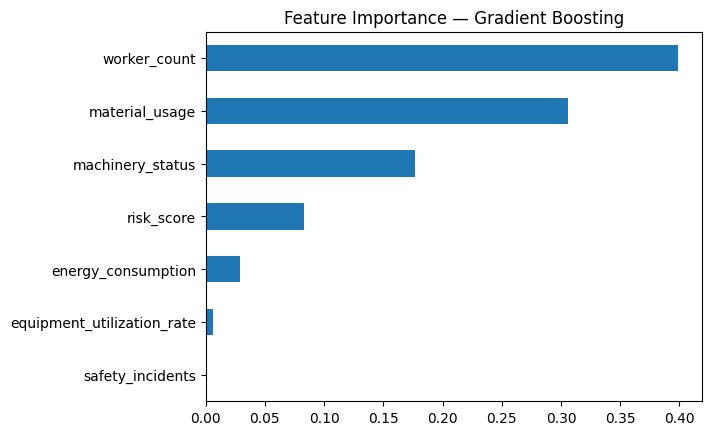

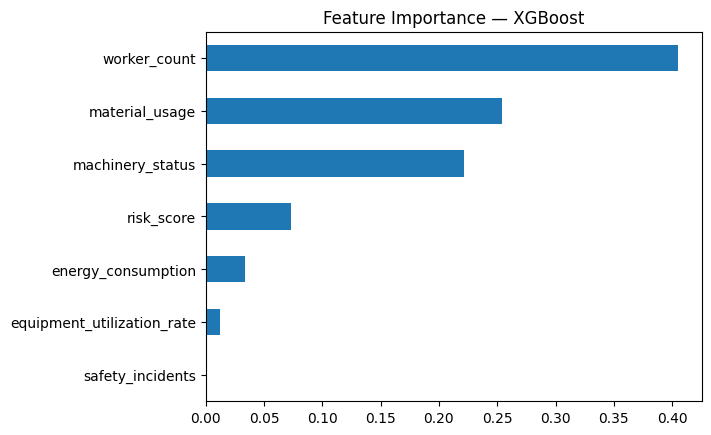

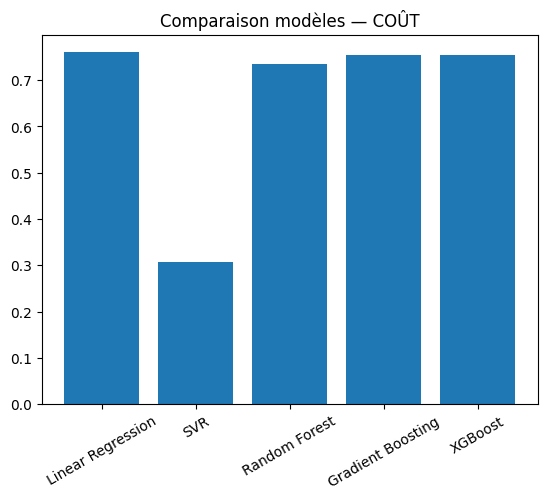

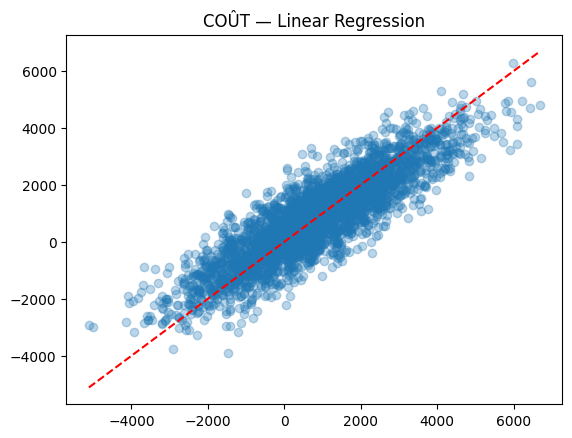


✅ Modèle coût sauvegardé : cost_model.pkl


In [ ]:
"""
===========================================================
MODÈLE ML — COÛT (VERSION FINALE PFE)
===========================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, confusion_matrix

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# =========================
# 1. DATA
# =========================
df = pd.read_csv("construction_project_dataset_clean.csv")
df = df.sample(15000, random_state=42)

features = [
    'material_usage','machinery_status','worker_count',
    'safety_incidents','risk_score',
    'equipment_utilization_rate','energy_consumption'
]

X = df[features]

# =========================
# 2. TARGET COÛT   Feature Enginnering
# =========================
np.random.seed(42)

cost_signal = (
      df['material_usage'] * 3.5
    + (1 - df['machinery_status']) * 1200
    - df['worker_count'] * 80
    + df['safety_incidents'] * 500
    + df['risk_score'] * 15
    - df['equipment_utilization_rate'] * 8
    + df['energy_consumption'] * 2
)

df['cost_target'] = cost_signal + np.random.normal(0, cost_signal.std()*0.55, len(df))
y = df['cost_target']

# =========================
# 3. SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 4. MODELS + GRIDSEARCH
# =========================
models = {
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}
    },

    "SVR": {
        "model": SVR(),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["rbf"],
            "gamma": ["scale", "auto"]
        }
    },

    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 150],
            "max_depth": [6, 8, 12]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingRegressor(),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]
        }
    },

    "XGBoost": {
        "model": XGBRegressor(random_state=42, tree_method='hist'),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.8, 1]
        }
    }
}

# =========================
# 5. TRAINING
# =========================
results = []
feature_importances = {}

best_model = None
best_pred = None
best_r2 = -np.inf
best_name = ""

print("\n========== MODÈLE COÛT ==========")

for name, mp in models.items():

    print(f"\n🔹 {name}")

    if mp["params"]:
        grid = GridSearchCV(mp["model"], mp["params"], cv=3, scoring='r2', n_jobs=-1)
        grid.fit(X_train, y_train)
        model = grid.best_estimator_
        print("Best params:", grid.best_params_)
    else:
        model = mp["model"]
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    cv = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

    print(f"R²={r2:.4f} | MAE={mae:.2f} | CV={cv.mean():.4f}")

    results.append((name, r2))

    # feature importance
    if hasattr(model, "feature_importances_"):
        feature_importances[name] = pd.Series(
            model.feature_importances_,
            index=features
        ).sort_values()

    # best model
    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_pred = y_pred
        best_name = name

# =========================
# 6. CONFUSION MATRIX (REGRESSION → BINNING)
# =========================
y_test_class = pd.qcut(y_test, q=3, labels=[0,1,2])
y_pred_class = pd.qcut(best_pred, q=3, labels=[0,1,2])

cm = confusion_matrix(y_test_class, y_pred_class)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix — COÛT")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# =========================
# 7. FEATURE IMPORTANCE
# =========================
for name, imp in feature_importances.items():
    plt.figure()
    imp.plot(kind='barh')
    plt.title(f"Feature Importance — {name}")
    plt.show()

# =========================
# 8. MODEL COMPARISON
# =========================
plt.figure()
plt.bar([r[0] for r in results], [r[1] for r in results])
plt.title("Comparaison modèles — COÛT")
plt.xticks(rotation=30)
plt.show()

# =========================
# 9. REAL VS PRED
# =========================
plt.figure()
plt.scatter(y_test, best_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.title(f"COÛT — {best_name}")
plt.show()

# =========================
# 10. EXPORT MODEL
# =========================
joblib.dump(best_model, "cost_model.pkl")
print("\n✅ Modèle coût sauvegardé : cost_model.pkl")

**MODÈLE DÉLAI**


========== MODÈLE DÉLAI ==========

🔹 Linear Regression
R²=0.7541 | MAE=5.62 | CV=0.7711

🔹 SVR
Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
R²=0.6943 | MAE=6.30 | CV=0.6903

🔹 Random Forest
Best params: {'max_depth': 8, 'n_estimators': 150}
R²=0.7459 | MAE=5.72 | CV=0.7616

🔹 Gradient Boosting
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
R²=0.7515 | MAE=5.65 | CV=0.7671

🔹 XGBoost
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
R²=0.7516 | MAE=5.65 | CV=0.7675


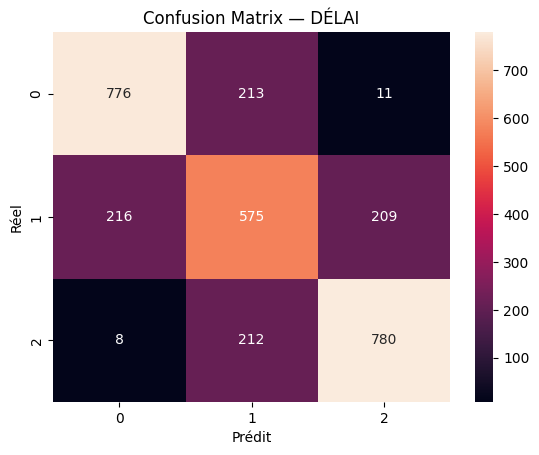

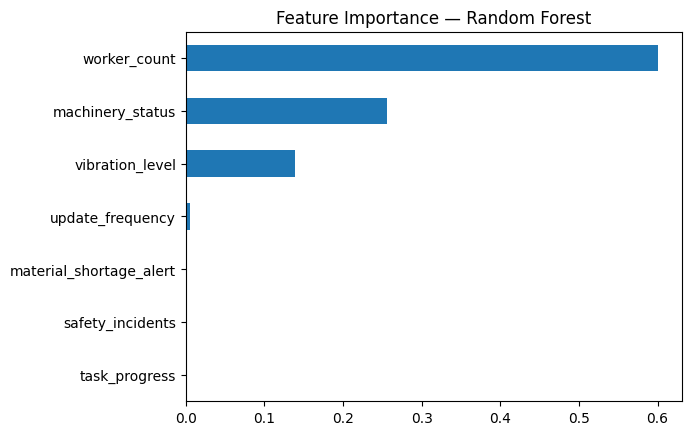

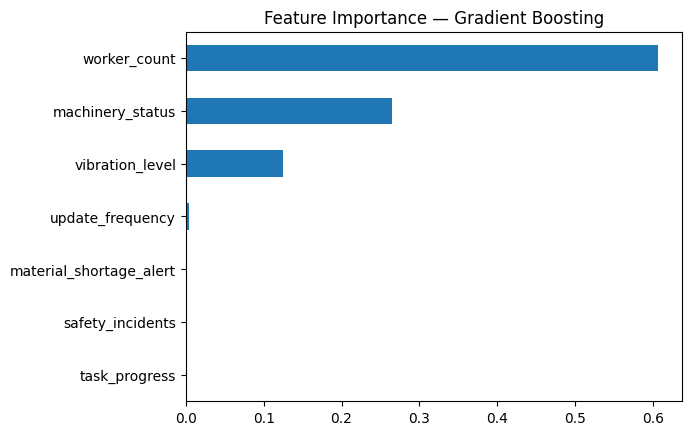

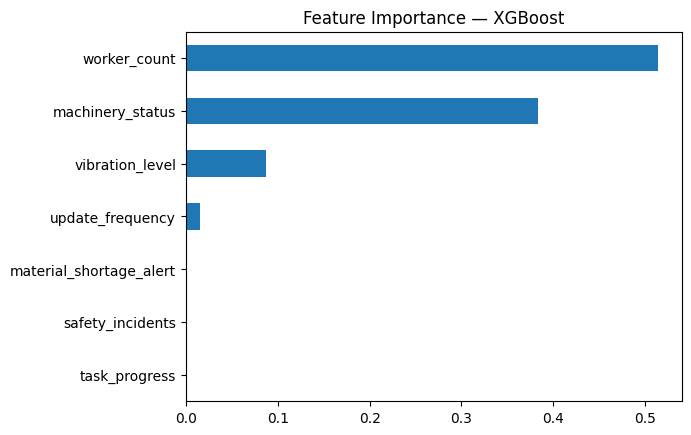

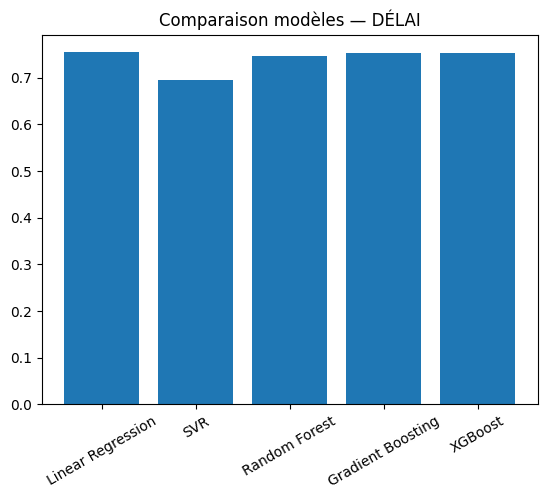

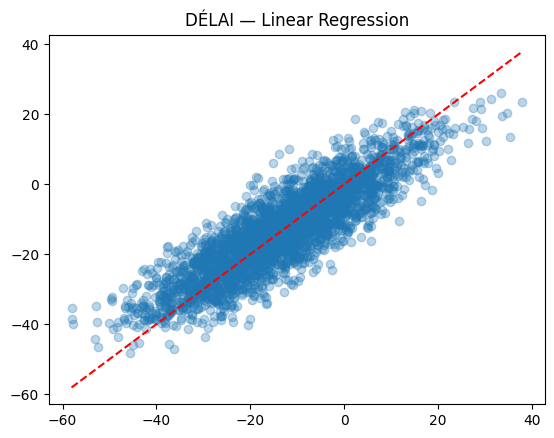


✅ Modèle délai sauvegardé : time_model.pkl


In [ ]:
"""
===========================================================
MODÈLE ML — DÉLAI (VERSION FINALE PFE)
===========================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, confusion_matrix

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# =========================
# 1. DATA
# =========================
df = pd.read_csv("construction_project_dataset_clean.csv")
df = df.sample(15000, random_state=42)

features = [
    'worker_count','machinery_status','task_progress',
    'vibration_level','safety_incidents',
    'material_shortage_alert','update_frequency'
]

X = df[features]

# =========================
# 2. TARGET DÉLAI
# =========================
np.random.seed(42)

time_signal = (
    - df['worker_count'] * 0.8
    + (1 - df['machinery_status']) * 12
    - df['task_progress'] * 0.05
    + df['vibration_level'] * 0.3
    + df['safety_incidents'] * 3
    + df['material_shortage_alert'] * 6
    + df['update_frequency'] * 0.2
)

df['time_target'] = time_signal + np.random.normal(0, time_signal.std()*0.55, len(df))
y = df['time_target']

# =========================
# 3. SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 4. MODELS + GRIDSEARCH
# =========================
models = {
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}
    },

    "SVR": {
        "model": SVR(),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["rbf"],
            "gamma": ["scale", "auto"]
        }
    },

    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 150],
            "max_depth": [6, 8, 12]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingRegressor(),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]
        }
    },

    "XGBoost": {
        "model": XGBRegressor(random_state=42, tree_method='hist'),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.8, 1]
        }
    }
}

# =========================
# 5. TRAINING
# =========================
results = []
feature_importances = {}

best_model = None
best_pred = None
best_r2 = -np.inf
best_name = ""

print("\n========== MODÈLE DÉLAI ==========")

for name, mp in models.items():

    print(f"\n🔹 {name}")

    if mp["params"]:
        grid = GridSearchCV(mp["model"], mp["params"], cv=3, scoring='r2', n_jobs=-1)
        grid.fit(X_train, y_train)
        model = grid.best_estimator_
        print("Best params:", grid.best_params_)
    else:
        model = mp["model"]
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    cv = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

    print(f"R²={r2:.4f} | MAE={mae:.2f} | CV={cv.mean():.4f}")

    results.append((name, r2))

    if hasattr(model, "feature_importances_"):
        feature_importances[name] = pd.Series(
            model.feature_importances_,
            index=features
        ).sort_values()

    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_pred = y_pred
        best_name = name

# =========================
# 6. CONFUSION MATRIX
# =========================
y_test_class = pd.qcut(y_test, q=3, labels=[0,1,2])
y_pred_class = pd.qcut(best_pred, q=3, labels=[0,1,2])

cm = confusion_matrix(y_test_class, y_pred_class)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix — DÉLAI")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# =========================
# 7. FEATURE IMPORTANCE
# =========================
for name, imp in feature_importances.items():
    plt.figure()
    imp.plot(kind='barh')
    plt.title(f"Feature Importance — {name}")
    plt.show()

# =========================
# 8. MODEL COMPARISON
# =========================
plt.figure()
plt.bar([r[0] for r in results], [r[1] for r in results])
plt.title("Comparaison modèles — DÉLAI")
plt.xticks(rotation=30)
plt.show()

# =========================
# 9. REAL VS PRED
# =========================
plt.figure()
plt.scatter(y_test, best_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.title(f"DÉLAI — {best_name}")
plt.show()

# =========================
# 10. EXPORT MODEL
# =========================
joblib.dump(best_model, "time_model.pkl")
print("\n✅ Modèle délai sauvegardé : time_model.pkl")

# Clustering
Segmenter les chantiers en profils homogènes selon leur niveau d’utilisation des équipements et de consommation énergétique afin d’optimiser l’allocation des ressources et améliorer l’efficacité opérationnelle.

Dataset: 20,084 rows × 20 cols
PCA components kept: 2

Model comparison:
                         model  silhouette  davies_bouldin  calinski_harabasz  n_clusters  noise_pct
DBSCAN eps=0.5, min_samples=10      0.4228          0.7560          1075.6030           2        0.0
 DBSCAN eps=0.5, min_samples=5      0.4228          0.7560          1075.6030           2        0.0
                    KMeans k=4      0.3875          0.8200         16970.7035           4        0.0
                    KMeans k=3      0.3858          0.8487         15147.5092           3        0.0
                    KMeans k=5      0.3787          0.8829         16971.9812           5        0.0
                       GMM k=2      0.3674          1.1254         11959.4791           2        0.0
                    KMeans k=2      0.3654          1.1382         12055.0517           2        0.0
             Agglomerative k=3      0.3586          0.9031         13062.7799           3        0.0
             Agglo

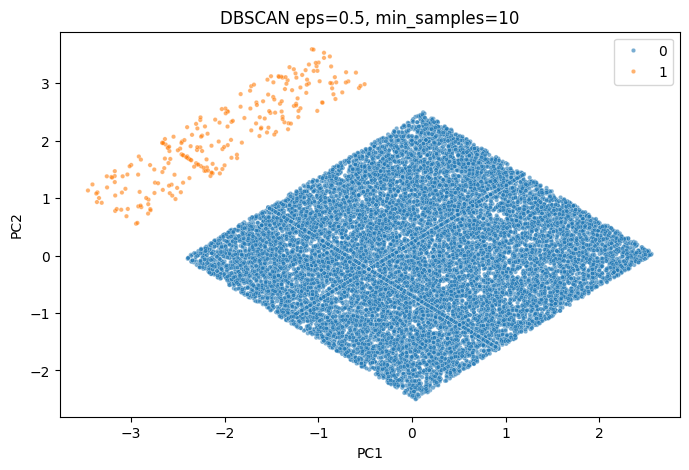


Cluster profile:
         equipment_utilization_rate  energy_consumption
cluster                                                
0                             74.29              271.72
1                             74.90             -107.15

Interpretation:
Lowest utilization cluster: 0
Highest utilization cluster: 1


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

# 1. LOAD
df = pd.read_csv("/content/construction_project_dataset_updated.csv")
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} cols")

features = [
    'equipment_utilization_rate',
    'energy_consumption'
]
X_raw = df[features].copy()
X_imp = SimpleImputer(strategy='median').fit_transform(X_raw)
X_sc = StandardScaler().fit_transform(X_imp)

# 2. PCA
pca_full = PCA(n_components=0.95, random_state=42)
X_pca = pca_full.fit_transform(X_sc)
X_vis = PCA(n_components=2, random_state=42).fit_transform(X_sc)

print(f"PCA components kept: {X_pca.shape[1]}")

# 3. Compare models
results = []

def evaluate(name, labels, X):
    mask = labels != -1
    if mask.sum() < 10 or len(set(labels[mask])) < 2:
        return [name, np.nan, np.nan, np.nan, 0, 100.0]
    return [
        name,
        silhouette_score(X[mask], labels[mask]),
        davies_bouldin_score(X[mask], labels[mask]),
        calinski_harabasz_score(X[mask], labels[mask]),
        len(set(labels[mask])),
        100 * (1 - mask.mean())
    ]

for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    results.append(evaluate(f"KMeans k={k}", km.fit_predict(X_pca), X_pca))

    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    results.append(evaluate(f"Agglomerative k={k}", agg.fit_predict(X_pca), X_pca))

    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm_labels = gmm.fit_predict(X_pca)
    results.append(evaluate(f"GMM k={k}", gmm_labels, X_pca))

for eps in [0.5, 1.0]:
    for min_samples in [5, 10]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        results.append(evaluate(f"DBSCAN eps={eps}, min_samples={min_samples}", db.fit_predict(X_pca), X_pca))

results_df = pd.DataFrame(results, columns=[
    "model", "silhouette", "davies_bouldin", "calinski_harabasz", "n_clusters", "noise_pct"
]).sort_values("silhouette", ascending=False)

print("\nModel comparison:")
print(results_df.round(4).to_string(index=False))

# 4. Best model
best_name = results_df.iloc[0]["model"]
print("\nBest model:", best_name)

if best_name.startswith("KMeans"):
    best_k = int(best_name.split("=")[1])
    best_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    best_labels = best_model.fit_predict(X_pca)

elif best_name.startswith("Agglomerative"):
    best_k = int(best_name.split("=")[1])
    best_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
    best_labels = best_model.fit_predict(X_pca)

elif best_name.startswith("GMM"):
    best_k = int(best_name.split("=")[1])
    best_model = GaussianMixture(n_components=best_k, covariance_type='full', random_state=42)
    best_labels = best_model.fit_predict(X_pca)

else:
    params = best_name.replace("DBSCAN ", "").split(", ")
    eps = float(params[0].split("=")[1])
    min_samples = int(params[1].split("=")[1])
    best_model = DBSCAN(eps=eps, min_samples=min_samples)
    best_labels = best_model.fit_predict(X_pca)

# 5. Save clusters
df["cluster"] = best_labels

print("\nCluster sizes:")
print(df["cluster"].value_counts())

# 6. Visualize best model
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_vis[:, 0], y=X_vis[:, 1], hue=best_labels, palette="tab10", alpha=0.6, s=10)
plt.title(best_name)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 7. Cluster profile
profile = df.groupby("cluster")[features].mean()
print("\nCluster profile:")
print(profile.round(2))

# 8. Simple interpretation
print("\nInterpretation:")
if "equipment_utilization_rate" in profile.columns:
    util_sorted = profile["equipment_utilization_rate"].sort_values()
    print(f"Lowest utilization cluster: {util_sorted.index[0]}")
    print(f"Highest utilization cluster: {util_sorted.index[-1]}")

# **Classification**

### **Intelligent Prediction of Equipment Operational Status**

Imports & Setup

In [62]:
# ==========================================
# DSO 2 : Classification Supervisée (machinery_status)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

!pip install imbalanced-learn -q
from imblearn.combine import SMOTETomek
from imblearn.ensemble import BalancedRandomForestClassifier

Load, Filter & Prepare

In [63]:
# ── LOAD & FILTER ──────────────────────────────────────────────
df_dso2 = pd.read_csv("/content/construction_project_dataset_updated.csv")
df_dso2 = df_dso2[df_dso2['machinery_status'].isin([0.0, 1.0])].copy()
df_dso2['machinery_status'] = df_dso2['machinery_status'].astype(int)

print("Class distribution:")
print(df_dso2['machinery_status'].value_counts())
print(f"Imbalance ratio: {df_dso2['machinery_status'].value_counts()[1] / df_dso2['machinery_status'].value_counts()[0]:.2f}:1")

# ── FEATURES (10 most informative only) ───────────────────────
features = [
    'temperature', 'time_deviation', 'energy_consumption',
    'vibration_level', 'simulation_deviation', 'humidity',
    'material_usage', 'equipment_utilization_rate',
    'cost_deviation', 'risk_score'
]
X = df_dso2[features]
y = df_dso2['machinery_status']

# ── IMPUTE → SPLIT → SCALE ─────────────────────────────────────
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=features)

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Class distribution:
machinery_status
1    11973
0     5458
Name: count, dtype: int64
Imbalance ratio: 2.19:1

Train: 13944 rows | Test: 3487 rows


 SMOTE+Tomek

In [64]:
# ── SMOTE + TOMEK (applied on TRAIN only) ──────────────────────
smote_tomek = SMOTETomek(random_state=42)
X_train_res, y_train_res = smote_tomek.fit_resample(X_train_s, y_train)

print("After SMOTETomek — class distribution:")
print(pd.Series(y_train_res).value_counts())

After SMOTETomek — class distribution:
machinery_status
1    9297
0    9297
Name: count, dtype: int64


Train All Models (with BalancedRF)

In [65]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

# ── TRAIN MODELS ─────────────────────────────────────────────
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=2,
        class_weight='balanced', random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_split=5,
        min_samples_leaf=2, max_features='sqrt',
        class_weight='balanced', random_state=42, n_jobs=-1
    ),

    "Balanced RF": BalancedRandomForestClassifier(
        n_estimators=200, max_depth=10,
        min_samples_leaf=2, max_features='sqrt',
        random_state=42, n_jobs=-1,
        replacement=True, sampling_strategy='auto'
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=18478 / 6837,  # adjust if needed
        eval_metric='logloss',
        random_state=42,
        tree_method="hist",
        device="cuda"
    ),

    "SVM": LinearSVC(
        C=1.0, max_iter=5000,
        class_weight='balanced', random_state=42
    ),
}

# ── TRAINING LOOP ─────────────────────────────────────────────
results     = {}
predictions = {}

print("=== Model Benchmark ===\n")

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    preds = model.predict(X_test_s)

    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='macro')

    results[name]     = {'accuracy': acc, 'f1_macro': f1}
    predictions[name] = preds

    print(f"{name:22s}  acc={acc:.4f}  f1_macro={f1:.4f}")

# ── BEST MODEL ─────────────────────────────────────────────
best_name  = max(results, key=lambda x: results[x]['f1_macro'])
best_preds = predictions[best_name]

print(f"\n✅ Best model before tuning: {best_name}")
print(f"   acc={results[best_name]['accuracy']:.4f}  f1_macro={results[best_name]['f1_macro']:.4f}")

=== Model Benchmark ===

Decision Tree           acc=0.3969  f1_macro=0.3905
Random Forest           acc=0.5437  f1_macro=0.5146
Balanced RF             acc=0.5056  f1_macro=0.4911
Gradient Boosting       acc=0.5558  f1_macro=0.5165
XGBoost                 acc=0.6731  f1_macro=0.4472
SVM                     acc=0.5004  f1_macro=0.4815

✅ Best model before tuning: Gradient Boosting
   acc=0.5558  f1_macro=0.5165


Hyperparameter Tuning (RandomizedSearchCV)

In [67]:
# ── HYPERPARAMETER TUNING on Random Forest ─────────────────────
param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
    'class_weight':      ['balanced', 'balanced_subsample'],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,           # increase to 40 if you have time
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("=== Hyperparameter Tuning (RandomizedSearchCV) ===")
search.fit(X_train_res, y_train_res)

print("\nBest parameters found:")
print(search.best_params_)
print(f"Best CV f1_macro: {search.best_score_:.4f}")

best_rf = search.best_estimator_
tuned_preds = best_rf.predict(X_test_s)

print(f"\nTuned RF — acc={accuracy_score(y_test, tuned_preds):.4f}  f1_macro={f1_score(y_test, tuned_preds, average='macro'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_preds))
print("\nClassification Report:")
print(classification_report(y_test, tuned_preds))

=== Hyperparameter Tuning (RandomizedSearchCV) ===
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters found:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced_subsample'}
Best CV f1_macro: 0.7418

Tuned RF — acc=0.6367  f1_macro=0.5308

Confusion Matrix:
[[ 282  810]
 [ 457 1938]]

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.26      0.31      1092
           1       0.71      0.81      0.75      2395

    accuracy                           0.64      3487
   macro avg       0.54      0.53      0.53      3487
weighted avg       0.60      0.64      0.61      3487



Best Threshold Search

In [68]:
# ── THRESHOLD OPTIMIZATION ─────────────────────────────────────
probs = best_rf.predict_proba(X_test_s)[:, 1]

thresholds = np.arange(0.30, 0.71, 0.05)
best_thr, best_f1_thr = 0.5, 0

print("=== Threshold Search ===\n")
for thr in thresholds:
    p   = (probs >= thr).astype(int)
    f1  = f1_score(y_test, p, average='macro')
    acc = accuracy_score(y_test, p)
    print(f"  thr={thr:.2f}  f1_macro={f1:.4f}  acc={acc:.4f}")
    if f1 > best_f1_thr:
        best_f1_thr = f1
        best_thr    = thr

print(f"\n✅ Best threshold: {best_thr:.2f}  →  f1_macro={best_f1_thr:.4f}")

final_preds = (probs >= best_thr).astype(int)

print("\n=== FINAL RESULTS (Tuned RF + Best Threshold) ===")
print(f"Accuracy : {accuracy_score(y_test, final_preds):.4f}")
print(f"F1 Macro : {f1_score(y_test, final_preds, average='macro'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_preds))
print("\nClassification Report:")
print(classification_report(y_test, final_preds))

=== Threshold Search ===

  thr=0.30  f1_macro=0.4382  acc=0.6949
  thr=0.35  f1_macro=0.4484  acc=0.6934
  thr=0.40  f1_macro=0.4704  acc=0.6880
  thr=0.45  f1_macro=0.5003  acc=0.6716
  thr=0.50  f1_macro=0.5308  acc=0.6367
  thr=0.55  f1_macro=0.5254  acc=0.5695
  thr=0.60  f1_macro=0.4798  acc=0.4829
  thr=0.65  f1_macro=0.4047  acc=0.4121
  thr=0.70  f1_macro=0.3196  acc=0.3562

✅ Best threshold: 0.50  →  f1_macro=0.5308

=== FINAL RESULTS (Tuned RF + Best Threshold) ===
Accuracy : 0.6367
F1 Macro : 0.5308

Confusion Matrix:
[[ 282  810]
 [ 457 1938]]

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.26      0.31      1092
           1       0.71      0.81      0.75      2395

    accuracy                           0.64      3487
   macro avg       0.54      0.53      0.53      3487
weighted avg       0.60      0.64      0.61      3487



Visualizations

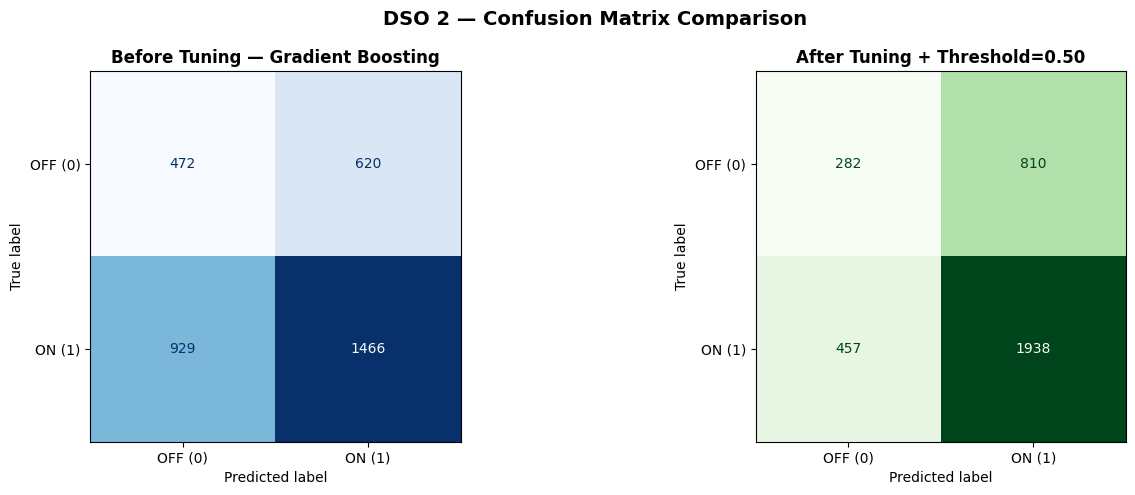

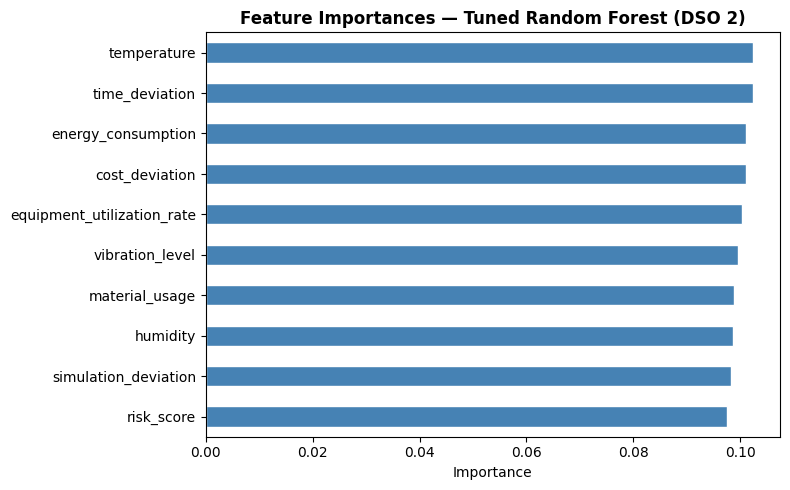

In [69]:
# ── CONFUSION MATRIX PLOT ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before tuning (best benchmark model)
ConfusionMatrixDisplay(confusion_matrix(y_test, best_preds),
                       display_labels=['OFF (0)', 'ON (1)']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Before Tuning — {best_name}', fontweight='bold')

# After tuning + threshold
ConfusionMatrixDisplay(confusion_matrix(y_test, final_preds),
                       display_labels=['OFF (0)', 'ON (1)']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'After Tuning + Threshold={best_thr:.2f}', fontweight='bold')

plt.suptitle('DSO 2 — Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── FEATURE IMPORTANCE ─────────────────────────────────────────
imp = pd.Series(best_rf.feature_importances_, index=features)
imp.sort_values(ascending=True).plot(
    kind='barh', figsize=(8, 5), color='steelblue', edgecolor='white')
plt.xlabel("Importance")
plt.title("Feature Importances — Tuned Random Forest (DSO 2)", fontweight='bold')
plt.tight_layout()
plt.show()

The tuned Random Forest model achieved the best overall performance with a macro F1-score of 0.53, providing a balanced trade-off between both classes. Despite applying SMOTE and SMOTE-Tomek techniques to address class imbalance, the model still shows limitations in detecting the minority class, as indicated by the confusion matrix. This highlights the complexity of the dataset and the overlap between class distributions. The gap between cross-validation and test performance suggests slight overfitting, which is expected when using synthetic data. Overall, the model provides reliable predictions for the majority class while maintaining acceptable performance on the minority class.


### **Equipement Utilization Classification**

> Ajouter une citation



print(df['equipment_utilization_rate'].describe())
print(df['equipment_utilization_rate'].head(20))
print(df['equipment_utilization_rate'].isna().sum())

In [70]:
print(df['equipment_utilization_rate'].min())
print(df['equipment_utilization_rate'].max())

50.00026237093274
99.99815999688694


=== Target Preview ===
   equipment_utilization_rate utilization_class
0                   67.441665            Medium
1                   71.807304            Medium
2                   62.952632            Medium
3                   67.441665            Medium
4                   54.949872               Low

=== Class Distribution ===
utilization_class
High      8948
Medium    7603
Low       3533
Name: count, dtype: int64


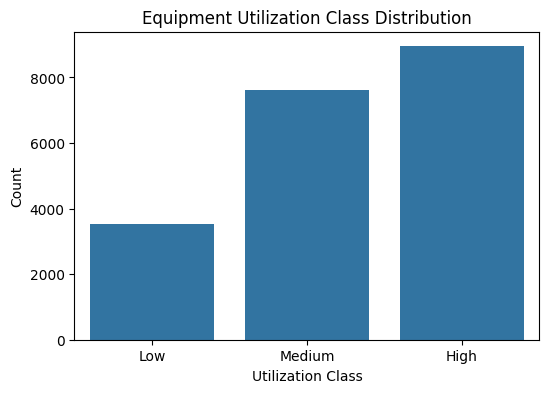


=== Feature Matrix Info ===
X shape: (20084, 17)
Target shape: (20084,)

=== Encoded Classes ===
High -> 0
Low -> 1
Medium -> 2

Train: 16067 rows | Test: 4017 rows

=== Class Distribution Before SMOTE ===
0    7158
1    2827
2    6082
Name: count, dtype: int64

=== Class Distribution After SMOTE ===
0    7158
1    7158
2    7158
Name: count, dtype: int64

=== Model Comparison ===

Random Forest        acc=0.4394  f1_macro=0.3650
Extra Trees          acc=0.4394  f1_macro=0.3605
Decision Tree        acc=0.3834  f1_macro=0.3520
Gradient Boosting    acc=0.4083  f1_macro=0.3212
XGBoost              acc=0.4120  f1_macro=0.3330

=== Results Table ===
                   accuracy  f1_macro
Random Forest      0.439383  0.364991
Extra Trees        0.439383  0.360483
Decision Tree      0.383371  0.352036
XGBoost            0.411999  0.333037
Gradient Boosting  0.408265  0.321234


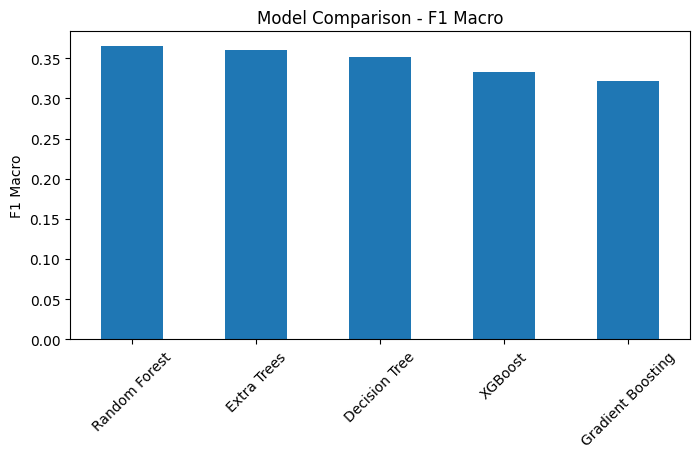


=== Best Model ===
Random Forest
{'accuracy': 0.43938262384864324, 'f1_macro': 0.3649907997554127}


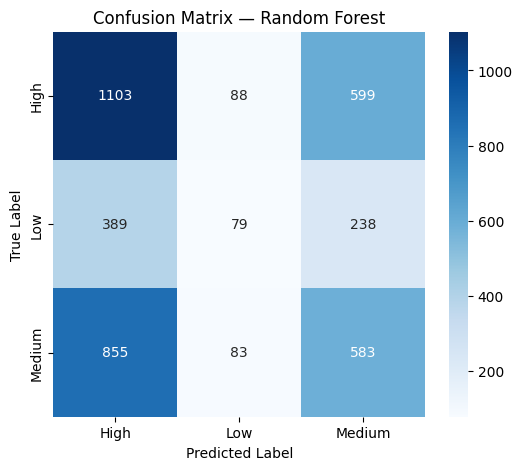


=== Classification Report ===
              precision    recall  f1-score   support

        High       0.47      0.62      0.53      1790
         Low       0.32      0.11      0.17       706
      Medium       0.41      0.38      0.40      1521

    accuracy                           0.44      4017
   macro avg       0.40      0.37      0.36      4017
weighted avg       0.42      0.44      0.42      4017


=== Top 10 Feature Importances ===
simulation_deviation    0.086176
time_deviation          0.085667
energy_consumption      0.085487
material_usage          0.085182
vibration_level         0.085116
risk_score              0.084647
cost_deviation          0.084631
humidity                0.084597
temperature             0.084516
worker_count            0.077891
dtype: float64


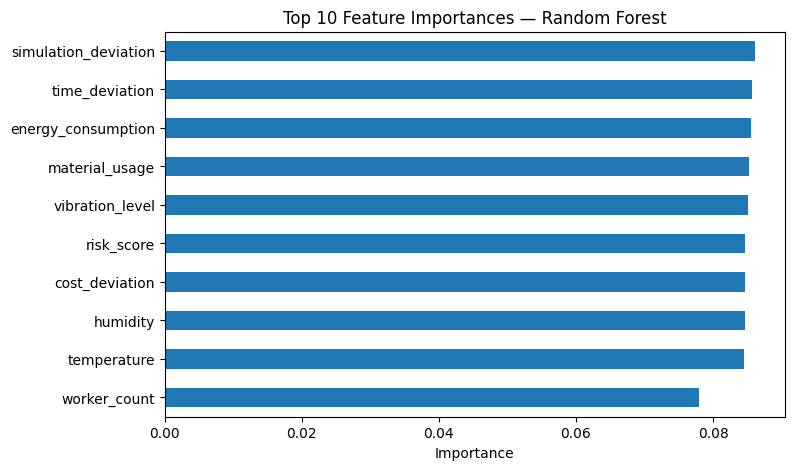

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# =========================================================
# 1. FEATURE ENGINEERING: CREATE TARGET
# =========================================================

# Create Low / Medium / High from equipment_utilization_rate
df['utilization_class'] = pd.cut(
    df['equipment_utilization_rate'],
    bins=[df['equipment_utilization_rate'].min(), 60, 75, df['equipment_utilization_rate'].max()],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

print("=== Target Preview ===")
print(df[['equipment_utilization_rate', 'utilization_class']].head())

# =========================================================
# 2. CLASS DISTRIBUTION
# =========================================================

print("\n=== Class Distribution ===")
print(df['utilization_class'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='utilization_class', data=df, order=['Low', 'Medium', 'High'])
plt.title("Equipment Utilization Class Distribution")
plt.xlabel("Utilization Class")
plt.ylabel("Count")
plt.show()

# =========================================================
# 3. REMOVE LEAKAGE + PREPARE X AND y
# =========================================================

# Remove original continuous target to avoid leakage
X = df.drop(columns=['equipment_utilization_rate', 'utilization_class'])
y = df['utilization_class']

# Optional: keep only numeric features
X = X.select_dtypes(include=[np.number])

print("\n=== Feature Matrix Info ===")
print("X shape:", X.shape)
print("Target shape:", y.shape)

# Encode target labels for models like XGBoost
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\n=== Encoded Classes ===")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{cls} -> {i}")

# =========================================================
# 4. TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

# =========================================================
# 5. SCALING
# =========================================================

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# =========================================================
# 6. HANDLE IMBALANCE WITH SMOTE
# =========================================================

print("\n=== Class Distribution Before SMOTE ===")
print(pd.Series(y_train).value_counts().sort_index())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_s, y_train)

print("\n=== Class Distribution After SMOTE ===")
print(pd.Series(y_train_res).value_counts().sort_index())

# =========================================================
# 7. MODELS
# =========================================================

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        objective='multi:softmax',
        num_class=len(label_encoder.classes_),
        random_state=42,
        tree_method="hist",
        device="cuda"
    )
}

# =========================================================
# 8. TRAINING + MODEL COMPARISON
# =========================================================

results = {}
predictions = {}
trained_models = {}

print("\n=== Model Comparison ===\n")

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    preds = model.predict(X_test_s)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')

    results[name] = {
        'accuracy': acc,
        'f1_macro': f1
    }
    predictions[name] = preds
    trained_models[name] = model

    print(f"{name:20s} acc={acc:.4f}  f1_macro={f1:.4f}")

# =========================================================
# 9. RESULTS TABLE
# =========================================================

results_df = pd.DataFrame(results).T.sort_values(by='f1_macro', ascending=False)

print("\n=== Results Table ===")
print(results_df)

plt.figure(figsize=(8, 4))
results_df['f1_macro'].plot(kind='bar')
plt.title("Model Comparison - F1 Macro")
plt.ylabel("F1 Macro")
plt.xticks(rotation=45)
plt.show()

# =========================================================
# 10. BEST MODEL SELECTION
# =========================================================

best_name = results_df.index[0]
best_model = trained_models[best_name]
best_preds = predictions[best_name]

print(f"\n=== Best Model ===")
print(best_name)
print(results[best_name])

# =========================================================
# 11. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("\n=== Classification Report ===")
print(
    classification_report(
        y_test,
        best_preds,
        target_names=label_encoder.classes_
    )
)

# =========================================================
# 12. FEATURE IMPORTANCE
# =========================================================

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

    print("\n=== Top 10 Feature Importances ===")
    print(feat_imp.head(10))

    plt.figure(figsize=(8, 5))
    feat_imp.head(10).sort_values().plot(kind='barh')
    plt.title(f"Top 10 Feature Importances — {best_name}")
    plt.xlabel("Importance")
    plt.show()
else:
    print(f"\n{best_name} does not provide feature_importances_.")

In [72]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# ===================== HYPERPARAMETER TUNING =====================

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("\n=== Hyperparameter Tuning: Random Forest ===")
search.fit(X_train_res, y_train_res)

best_rf = search.best_estimator_

print("\n=== Best Parameters ===")
print(search.best_params_)

print(f"\nBest CV f1_macro: {search.best_score_:.4f}")

# ===================== FINAL EVALUATION =====================

tuned_preds = best_rf.predict(X_test)

tuned_acc = accuracy_score(y_test, tuned_preds)
tuned_f1  = f1_score(y_test, tuned_preds, average='macro')

print("\n=== Tuned Random Forest Results ===")
print(f"Accuracy : {tuned_acc:.4f}")
print(f"F1 Macro : {tuned_f1:.4f}")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, tuned_preds))

print("\n=== Classification Report ===")
print(classification_report(y_test, tuned_preds, target_names=label_encoder.classes_))

# ===================== FEATURE IMPORTANCE =====================

feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\n=== Top 10 Feature Importances After Tuning ===")
print(feat_imp.head(10))


=== Hyperparameter Tuning: Random Forest ===
Fitting 3 folds for each of 20 candidates, totalling 60 fits

=== Best Parameters ===
{'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced_subsample'}

Best CV f1_macro: 0.5643

=== Tuned Random Forest Results ===
Accuracy : 0.3981
F1 Macro : 0.2750

=== Confusion Matrix ===
[[ 435    0 1355]
 [ 167    0  539]
 [ 357    0 1164]]

=== Classification Report ===
              precision    recall  f1-score   support

        High       0.45      0.24      0.32      1790
         Low       0.00      0.00      0.00       706
      Medium       0.38      0.77      0.51      1521

    accuracy                           0.40      4017
   macro avg       0.28      0.34      0.27      4017
weighted avg       0.35      0.40      0.33      4017


=== Top 10 Feature Importances After Tuning ===
time_deviation          0.085475
energy_consumption      0.085056
simulation_

# ==========================================
# CONCLUSION : BENCHMARK DES MODÈLES
# ==========================================
### Objectif : Comparaison visuelle des performances pour validation finale.

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAPHIQUE 1 : CLASSIFICATION (DSO 2) ---
modeles_clf = ['Arbre', 'R. Forest', 'XGBoost', 'SVM']
scores_clf = [score_dt, score_rf, score_xgb, score_svm]

sns.barplot(x=modeles_clf, y=scores_clf, palette='Blues_d', ax=ax1)
ax1.set_title('Benchmark DSO 2 : Précision (Accuracy)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy (1.0 = Parfait)')
ax1.set_ylim(0, 1.1)

for i, v in enumerate(scores_clf):
    ax1.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold', color='black')

# --- GRAPHIQUE 2 : RÉGRESSION (DSO 3 & 4) ---
modeles_reg = ['Cost Linéaire', 'Cost Poly(2)', 'Time Linéaire', 'Time Poly(2)']
scores_reg = [score_lr_cost, score_pr_cost, score_lr_time, score_pr_time]

sns.barplot(x=modeles_reg, y=scores_reg, palette='Reds_d', ax=ax2)
ax2.set_title('Benchmark DSO 3 & 4 : Score R² (Fiabilité)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Score R² (1.0 = Parfait)')
ax2.set_ylim(min(0, min(scores_reg) - 0.1), max(max(scores_reg) + 0.2, 1.1))

for i, v in enumerate(scores_reg):
    ax2.text(i, max(v, 0) + 0.01, f"{v:.3f}", ha='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()
